# Ideal Gas Orbit

An open (wall-less) domain with a central point mass: particles are given tangential initial velocities around the center and pulled inward by an inverse-square field, while still colliding elastically with each other -- a toy orbiting/proto-planetary gas cloud. Uses the shared `ideal_gas.py` module's `central_gravity` acceleration field.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import ideal_gas as ig

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ig.configure_ffmpeg()

In [2]:
N = 15000
dt = 8e-6
t_steps = 500
v0 = 450.0
L = 2.0
radius = 0.0005
center = (1.0, 1.0)

r = L * torch.rand((2, N), device=device)
ixr, ixl = r[0] > 1, r[0] <= 1
v = torch.zeros((2, N), device=device)
v[0] = -v0 * (r[1] - center[1])
v[1] = v0 * (r[0] - center[0])

rs, vs, _ = ig.motion(r, v, ts=t_steps, dt=dt, d_cutoff=2 * radius, L=L,
                      accel_fn=ig.central_gravity(center=center, gc=0.5e5),
                      reflect_x_lo=False, reflect_x_hi=False, reflect_y_lo=False, reflect_y_hi=False,
                      track_pressure=False)

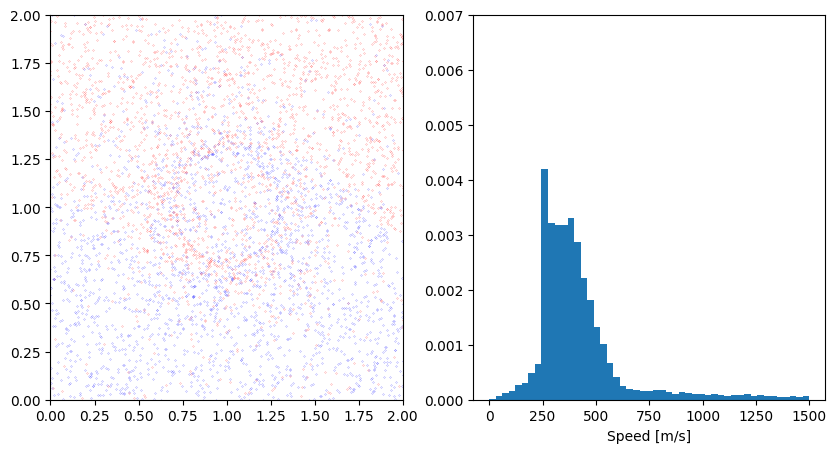

In [3]:
bins = np.linspace(0, 1500, 50)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = 0, L
axes[0].set_xlim(0, L)
axes[0].set_ylim(0, L)
markersize = 2 * radius * axes[0].get_window_extent().width / (vmax - vmin) * 72. / fig.dpi
red, = axes[0].plot([], [], 'o', color='red', markersize=markersize)
blue, = axes[0].plot([], [], 'o', color='blue', markersize=markersize)

n, _, patches = axes[1].hist(torch.sqrt(torch.sum(vs[0]**2, axis=0)).cpu(), bins=bins, density=True)
axes[1].set_ylim(top=0.007)
axes[1].set_xlabel('Speed [m/s]')

stride = ig.frame_stride(t_steps)
n_frames = t_steps // stride

def animate(frame):
    i = frame * stride
    xred, yred = rs[i][0][ixr].cpu(), rs[i][1][ixr].cpu()
    xblue, yblue = rs[i][0][ixl].cpu(), rs[i][1][ixl].cpu()
    red.set_data(xred, yred)
    blue.set_data(xblue, yblue)
    hist, _ = np.histogram(torch.sqrt(torch.sum(vs[i]**2, axis=0)).cpu(), bins=bins, density=True)
    for j, patch in enumerate(patches):
        patch.set_height(hist[j])
    return red, blue

ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=50, blit=True)
ani.save(os.path.join(MEDIA, "ideal_gas_orbit.mp4"), writer="ffmpeg", fps=30)
plt.show()